In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Mounted at /content/drive


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
import os
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używam urządzenia: {device}")

NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 128
NUM_EPOCHS = 100
learning_rate = 0.001
weight_decay = 1e-3
grad_clip = None

Używam urządzenia: cuda


In [16]:
model_name = "Inception"
date = "251216"
run_id = f"{date}_{model_name}_epoch100"
base_directory = "/content/drive/MyDrive/TAI/sem2/DL/inception_128"
project_directory = os.path.join(base_directory, run_id)
os.makedirs(project_directory, exist_ok=True)

In [9]:
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.2435, 0.2616]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dane załadowane.")

Dane załadowane.


In [ ]:
class InceptionModule(nn.Module):
    """
    Inception v1 module:
    - 1x1
    - 1x1 -> 3x3
    - 1x1 -> 5x5
    - 3x3 pool -> 1x1

    Różnice vs oryginał GoogLeNet:
    - BatchNorm po każdym conv
    - zmniejszone filtry
    """

    def __init__(self, in_channels,n1x1, n3x3red, n3x3, n5x5red, n5x5, pool_proj):
        super().__init__()

        # 1x1 conv
        self.b1 = nn.Sequential(
            nn.Conv2d(in_channels, n1x1, kernel_size=1, bias=False),
            nn.BatchNorm2d(n1x1),
            nn.ReLU(inplace=True)
        )

        # 1x1 -> 3x3 conv
        self.b2 = nn.Sequential(
            nn.Conv2d(in_channels, n3x3red, kernel_size=1, bias=False),
            nn.BatchNorm2d(n3x3red),
            nn.ReLU(inplace=True),
            nn.Conv2d(n3x3red, n3x3, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(n3x3),
            nn.ReLU(inplace=True)
        )

        # 1x1 -> 5x5 conv
        self.b3 = nn.Sequential(
            nn.Conv2d(in_channels, n5x5red, kernel_size=1, bias=False),
            nn.BatchNorm2d(n5x5red),
            nn.ReLU(inplace=True),
            nn.Conv2d(n5x5red, n5x5, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(n5x5),
            nn.ReLU(inplace=True)
        )

        # 3x3 pool -> 1x1 conv
        self.b4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1, bias=False),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

In [ ]:
class InceptionCIFAR(nn.Module):
    """
    wzorowany na Inception v1 (GoogLeNet)

    Różnice:
    1. Wejście:
       - 3x3 conv stride=1 zamiast 7x7 stride=2
       - brak poolingu na początku
    2. Architektura:
       - Mniej modułów
       - Węższe kanały (mniej parametrów)
    3. Brak auxiliary classifiers
    4. AdaptiveAvgPool(1x1) zamiast 7x7
    5. BatchNorm w całej sieci
    """

    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()

        # zmiana: 7x7 stride=2 ->  3x3 stride=1
        self.stem = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True)
        )

        # ---- Inception blocks 32x32 ----
        self.inception3a = InceptionModule(96, 32, 48, 64, 8, 16, 16)
        self.inception3b = InceptionModule(128, 64, 64, 96, 16, 32, 32)
        self.maxpool1 = nn.MaxPool2d(3, stride=2, padding=1)  # 32x32 -> 16x16

        # ---- 16x16 ----
        self.inception4a = InceptionModule(224, 96, 48, 104, 8, 24, 32)
        self.inception4b = InceptionModule(256, 80, 64, 128, 16, 32, 32)
        self.maxpool2 = nn.MaxPool2d(3, stride=2, padding=1)  # 16x16 -> 8x8

        # ---- 8x8 ----
        self.inception5a = InceptionModule(272, 128, 80, 160, 16, 48, 48)
        self.inception5b = InceptionModule(384, 192, 96, 192, 24, 64, 64)

        # zmiana: 7x7 avg pool -> adaptive 1x1
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)

        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool1(x)

        x = self.inception4a(x)
        x = self.inception4b(x)
        x = self.maxpool2(x)

        x = self.inception5a(x)
        x = self.inception5b(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

In [ ]:
def train_step(model:nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer,
               scheduler:torch.optim.lr_scheduler,
               grad_clip:float):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X,y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    if grad_clip:
      nn.utils.clip_grad_value_(model.parameters(), grad_clip)
    optimizer.step()
    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y)
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  if scheduler is not None:
    scheduler.step(train_loss)
  return train_loss, train_acc

def test_step(model:nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:nn.Module):
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()
      test_pred_labels = torch.argmax(test_pred_logits, dim=1)
      test_acc += (test_pred_labels == y).sum().item() / len(y)
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          scheduler:torch.optim.lr_scheduler,
          grad_clip:float,
          loss_fn: torch.nn.Module,
          epochs: int):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, scheduler, grad_clip)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn)
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
    return results

def plot_loss_curves(results: Dict[str, List[float]], save_path: str = None, model_name: str = None, learning_rate: float = None, weight_decay: float = None, grad_clip: float = None):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    epochs = range(len(results['train_loss']))
    title_suffix = model_name
    if learning_rate is not None: title_suffix += f" | Learning rate: {learning_rate}"
    if weight_decay is not None: title_suffix += f" | Weight decay: {weight_decay}"
    if grad_clip is not None: title_suffix += f" | Grad clip: {grad_clip}"
    title_suffix += f" | Epochs: {len(results['train_loss'])}"
    title_suffix += f" | Batch size: {BATCH_SIZE}"
    plt.figure(figsize=(15, 7))
    plt.suptitle(title_suffix, fontsize=16)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title(f'Loss')
    plt.xlabel('Epochs')
    plt.grid()
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title(f'Accuracy')
    plt.xlabel('Epochs')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to: {save_path}")
    plt.show()

Rozpoczynam trening modelu Inception...


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:204: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch: 1 | train_loss: 1.8328 | train_acc: 0.3140 | test_loss: 1.5546 | test_acc: 0.4105
Epoch: 2 | train_loss: 1.4564 | train_acc: 0.4647 | test_loss: 1.2704 | test_acc: 0.5315
Epoch: 3 | train_loss: 1.2617 | train_acc: 0.5458 | test_loss: 1.1439 | test_acc: 0.5943
Epoch: 4 | train_loss: 1.1379 | train_acc: 0.5931 | test_loss: 1.0266 | test_acc: 0.6361
Epoch: 5 | train_loss: 1.0491 | train_acc: 0.6258 | test_loss: 1.1004 | test_acc: 0.6163
Epoch: 6 | train_loss: 0.9800 | train_acc: 0.6525 | test_loss: 0.8953 | test_acc: 0.6826
Epoch: 7 | train_loss: 0.9218 | train_acc: 0.6731 | test_loss: 0.8534 | test_acc: 0.7010
Epoch: 8 | train_loss: 0.8749 | train_acc: 0.6916 | test_loss: 0.9160 | test_acc: 0.6821
Epoch: 9 | train_loss: 0.8270 | train_acc: 0.7095 | test_loss: 0.7407 | test_acc: 0.7408
Epoch: 10 | train_loss: 0.7912 | train_acc: 0.7210 | test_loss: 0.7691 | test_acc: 0.7341
Epoch: 11 | train_loss: 0.7531 | train_acc: 0.7365 | test_loss: 0.7321 | test_acc: 0.7418
Epoch: 12 | train_l

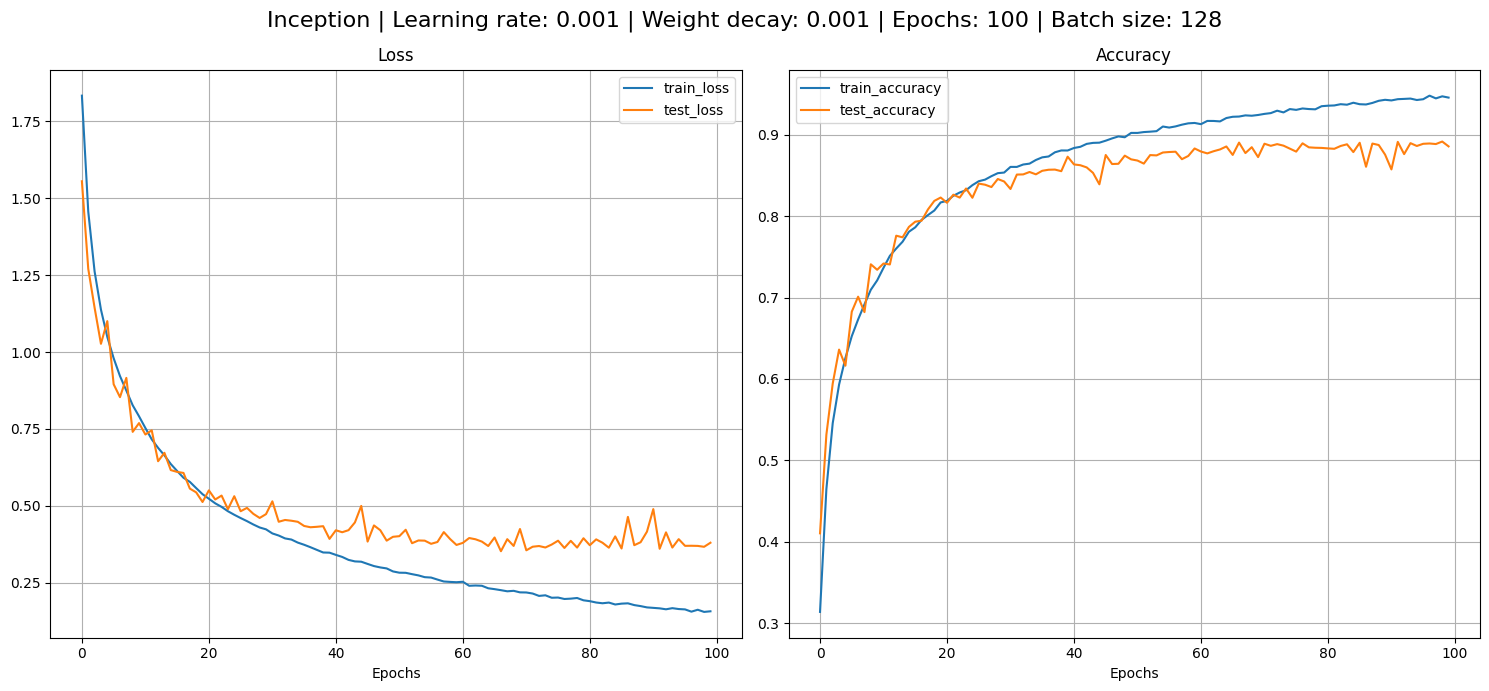

In [17]:
model = InceptionCIFAR(num_classes=10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS-5)

print("Rozpoczynam trening modelu Inception...")
start_time = timer()
model_results = train(model, train_dataloader, test_dataloader, optimizer, scheduler, grad_clip, loss_fn, NUM_EPOCHS)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

plot_loss_curves(model_results,
                 save_path=os.path.join(project_directory, f"model_{model_name}_loss_curves.png"),
                 model_name=model_name,
                 learning_rate=learning_rate,
                 weight_decay=weight_decay,
                 grad_clip=grad_clip)

  0%|          | 0/79 [00:00<?, ?it/s]

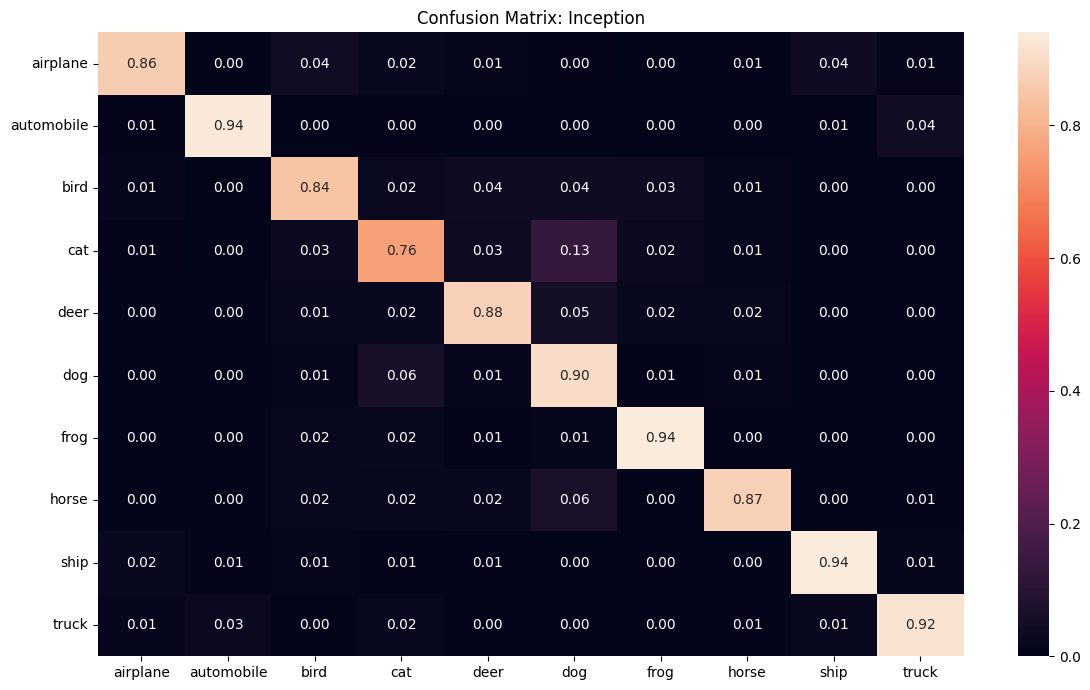

              precision    recall  f1-score   support

    airplane       0.93      0.86      0.90      1000
  automobile       0.96      0.94      0.95      1000
        bird       0.86      0.84      0.85      1000
         cat       0.80      0.76      0.78      1000
        deer       0.87      0.88      0.87      1000
         dog       0.75      0.90      0.82      1000
        frog       0.91      0.94      0.92      1000
       horse       0.94      0.87      0.90      1000
        ship       0.94      0.94      0.94      1000
       truck       0.92      0.92      0.92      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Model zapisany do: /content/drive/MyDrive/TAI/sem2/DL/inception_128/251216_Inception_epoch100/model_Inception_cifar10_251216.pth


In [ ]:
predicted_labels = []
actual_labels = []
model.eval()
class_names = train_dataset.classes

with torch.no_grad():
  for images, labels in tqdm(DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)):
    images, labels = images.to(device), labels.to(device)
    prediction_logits = model(images)
    predictions = prediction_logits.argmax(dim=1).cpu().numpy()
    predicted_labels.extend(predictions)
    actual_labels.extend(labels.cpu().numpy())

confusion_mat = confusion_matrix(actual_labels, predicted_labels)
# Normalizacja i wyświetlenie
confusion_df = pd.DataFrame(confusion_mat/np.sum(confusion_mat)*10, index=class_names, columns=class_names)

plt.figure(figsize=(12,7))
sn.heatmap(confusion_df, annot=True, fmt='.2f')
plt.title(f"Confusion Matrix: {model_name}")
plt.tight_layout()
if project_directory:
    plt.savefig(os.path.join(project_directory, f"confusion_matrix_model_{model_name}.png"))
plt.show()

report = classification_report(actual_labels, predicted_labels, target_names=class_names)
print(report)

if project_directory:
    with open(os.path.join(project_directory, f"classification_report_{model_name}.txt"), "w") as f:
        f.write(report)

# ZAPIS MODELU
save_path = os.path.join(project_directory, f"model_{model_name}_cifar10_{date}.pth")
torch.save(model.state_dict(), save_path)
print(f"Model zapisany do: {save_path}")